In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle


In [4]:
train_dir = '/content/drive/MyDrive/MRI Images/Training/'
test_dir = '/content/drive/MyDrive/MRI Images/Testing/'

train_paths, train_labels = [], []
for label in os.listdir(train_dir):
    label_path = os.path.join(train_dir, label)
    if os.path.isdir(label_path):
        for image in os.listdir(label_path):
            train_paths.append(os.path.join(label_path, image))
            train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

test_paths, test_labels = [], []
for label in os.listdir(test_dir):
    label_path = os.path.join(test_dir, label)
    if os.path.isdir(label_path):
        for image in os.listdir(label_path):
            test_paths.append(os.path.join(label_path, image))
            test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)


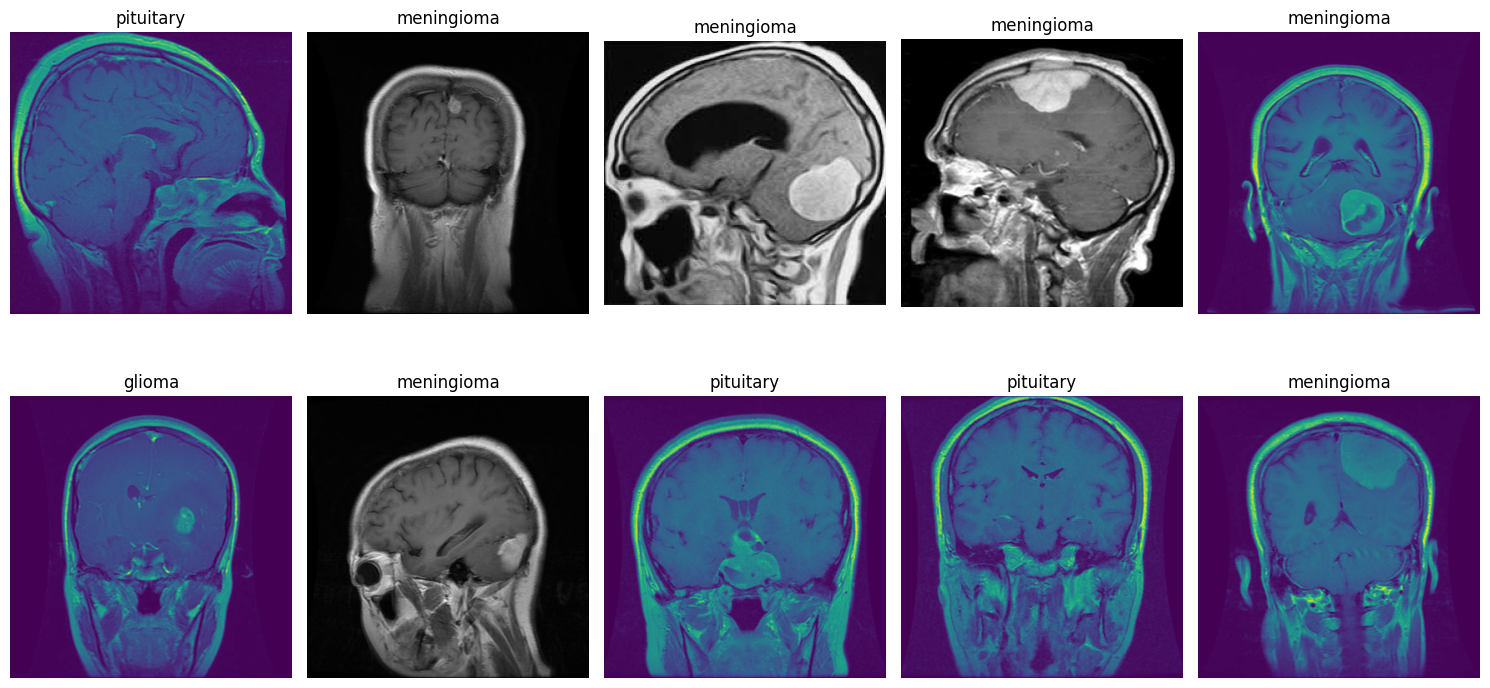

In [5]:
random_indices = random.sample(range(len(train_paths)), 10)
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()
for i, index in enumerate(random_indices):
    img = Image.open(train_paths[index])
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(train_labels[index])
plt.tight_layout()
plt.show()

In [6]:
IMAGE_SIZE = 128

def augment_image(image):
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    return image

def open_images(paths):
    images = []
    for path in paths:
        img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img = augment_image(img)
        img = img_to_array(img) / 255.0
        images.append(img)
    return np.array(images)

def encode_label(labels):
    unique_labels = sorted(list(set(labels)))
    label_map = {label: idx for idx, label in enumerate(unique_labels)}
    encoded = np.array([label_map[l] for l in labels])
    return encoded

def datagen(paths, labels, batch_size=12, epochs=1):
    encoded_labels = encode_label(labels)
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i+batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = encoded_labels[i:i+batch_size]
            yield batch_images, batch_labels


In [8]:
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last few layers for fine-tuning
for i in range(-4, 0):
    base_model.layers[i].trainable = True

model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    Flatten(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(os.listdir(train_dir)), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',  # ✅ fixed typo
    metrics=['sparse_categorical_accuracy']
)

# ------------------- Training -------------------
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 5

history = model.fit(
    datagen(train_paths, train_labels, batch_size, epochs),
    steps_per_epoch=steps,
    epochs=epochs
)


Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1423s 5s/step - loss: 0.6562 - sparse_categorical_accuracy: 0.7435
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1402s 5s/step - loss: 0.2455 - sparse_categorical_accuracy: 0.9138
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1401s 5s/step - loss: 0.1858 - sparse_categorical_accuracy: 0.9257
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1394s 5s/step - loss: 0.1297 - sparse_categorical_accuracy: 0.9502
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1401s 5s/step - loss: 0.0905 - sparse_categorical_accuracy: 0.9649


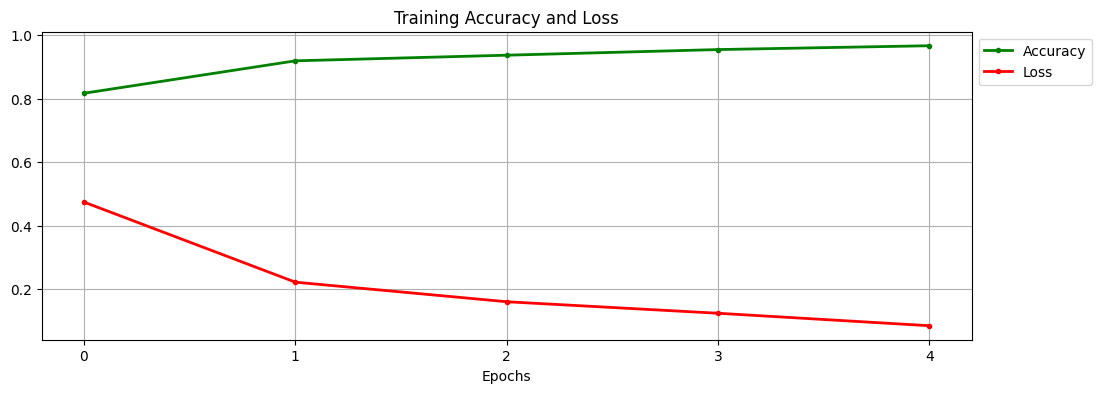

In [9]:
plt.figure(figsize=(12, 4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Training Accuracy and Loss')
plt.xlabel('Epochs')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'],loc='upper left', bbox_to_anchor=(1,1))
plt.show()

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)

print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))


41/41 ━━━━━━━━━━━━━━━━━━━━ 264s 6s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       300
           1       0.93      0.94      0.94       306
           2       0.99      1.00      0.99       405
           3       1.00      0.95      0.98       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311



Confusion Matrix:
[[285  14   1   0]
 [ 17 287   2   0]
 [  1   0 404   0]
 [  6   6   2 286]]


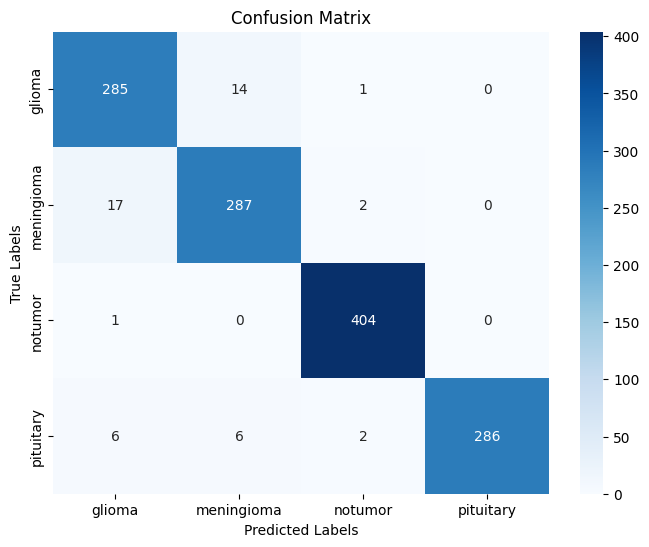

In [11]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(os.listdir(train_dir)), yticklabels=sorted(os.listdir(train_dir)))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

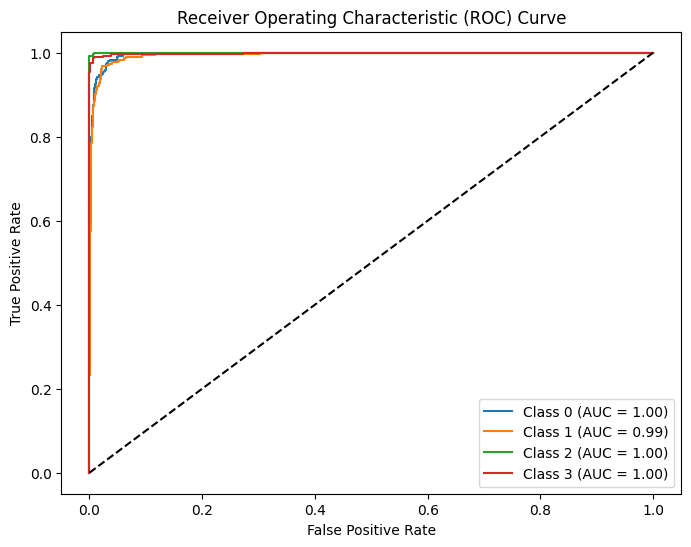

In [12]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], linestyle='--', color='black')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [28]:
model.save('model.h5')

In [29]:
from tensorflow.keras.models import load_model
model = load_model('model.h5')

In [30]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']
class_labels = sorted(os.listdir(train_dir))


def detect_and_display(image_path, model):
    try:
        # Load and preprocess the image
        img = load_img(image_path, target_size=(128, 128))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0  # normalize

        # Make prediction
        prediction = model.predict(img_array)
        predicted_class_index = np.argmax(prediction)
        confidence_score = np.max(prediction, axis=1)[0]

        # Determine result
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor Detected"
        else:
            result = f"Tumor Detected: {class_labels[predicted_class_index]}"

        # Display image and result
        plt.imshow(load_img(image_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

        return result

    except Exception as e:
        print("Error processing the image:", str(e))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 808ms/step


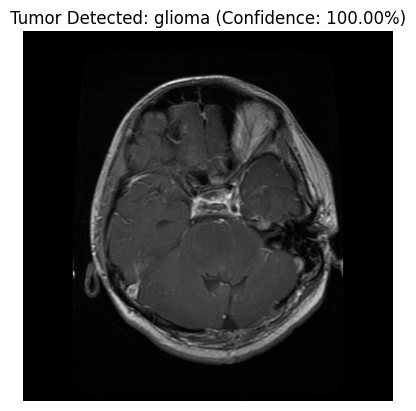

'Tumor Detected: glioma'

In [31]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0010.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step


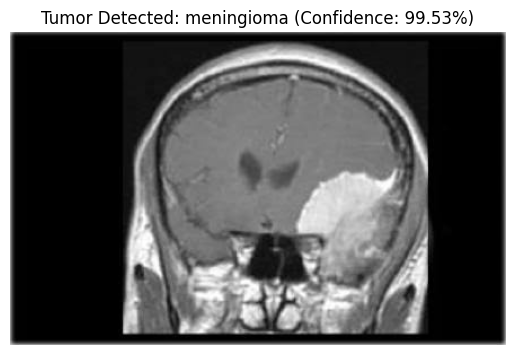

'Tumor Detected: meningioma'

In [32]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-meTr_0000.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step


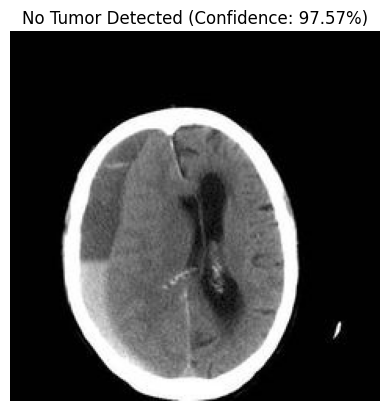

'No Tumor Detected'

In [33]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-noTr_0000.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step


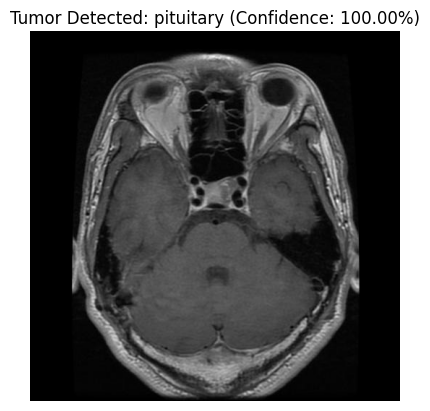

'Tumor Detected: pituitary'

In [34]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-piTr_0000.jpg'
detect_and_display(image_path, model)